# Task 3: Slab-based 3D U-Net for BraTS Multi-modal MRI Segmentation

This notebook adds a true Conv3d-based 3D U-Net experiment. It keeps the patient-level split and reads the existing preprocessed 2D slice `.npz` files, but each sample is a fixed-depth 3D slab: image `[4, D, H, W]`, label `[3, D, H, W]`.


## 1. Imports


In [1]:
import os
import csv
import random
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader

from task2_attention_unet_utils import (
    collect_files_for_cases,
    split_cases_patient_level,
    write_case_list,
)
import task3_unet3d_utils as u

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))


PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA device: NVIDIA GeForce RTX 2080 Ti


/public/home/CS177/zhouzhj2023-cs177/miniforge3/envs/bmeproj2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

Defaults are conservative for 3D memory use. If CUDA runs out of memory, lower `BASE_CHANNELS` to `8`, lower `SLAB_DEPTH` to `8`, or keep `BATCH_SIZE = 1`.


In [2]:
DATA_ROOT = Path("outputs_task1/processed_slices")
if not DATA_ROOT.exists():
    fallback_data_root = Path(r"D:\Imaging\project2\processed_slices")
    if fallback_data_root.exists():
        DATA_ROOT = fallback_data_root

IMAGE_KEY = "image"
LABEL_KEY = "label"

NUM_MODALITIES = 4
OUT_CHANNELS = 3
SLAB_DEPTH = 5
SLAB_MODE = "center"  # "center" is recommended; "start" is also supported.

IMAGE_HEIGHT = 192
IMAGE_WIDTH = 208
REGION_NAMES = ["WT", "TC", "ET"]

SEED = 42
TRAIN_RATIO = 0.65
VAL_RATIO = 0.20
TEST_RATIO = 0.15

BATCH_SIZE = 8
NUM_EPOCHS = 50
TOTAL_EPOCHS = NUM_EPOCHS
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
BASE_CHANNELS = 32
USE_ATTENTION_UNET_3D = False
NORM_LAYER_3D = "instance"

# Depth pooling is disabled by default so D=3/5/7/16 slabs all work.
# Conv3d kernels still model through-depth context.
POOL_KERNEL_3D = (1, 2, 2)
UPSAMPLE_SCALE_3D = (1, 2, 2)

NUM_WORKERS = 0
USE_AUGMENTATION = True
USE_AMP = True
RUN_BACKWARD_SMOKE_TEST = True

THRESHOLD = 0.5
VIS_EVERY_N_EPOCHS = 5
EARLY_STOPPING_PATIENCE = 20

MODEL_NAME = "attunet3d" if USE_ATTENTION_UNET_3D else "unet3d"
EXPERIMENT_NAME = f"{MODEL_NAME}_slab{SLAB_DEPTH}"
OUTPUT_DIR = Path(f"outputs_task3_{EXPERIMENT_NAME}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if SLAB_DEPTH <= 0:
    raise ValueError(f"SLAB_DEPTH must be positive, got {SLAB_DEPTH}")
if SLAB_MODE not in {"center", "start"}:
    raise ValueError(f"SLAB_MODE must be 'center' or 'start', got {SLAB_MODE}")

print("DATA_ROOT:", DATA_ROOT.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
print("EXPERIMENT_NAME:", EXPERIMENT_NAME)
print("DEVICE:", DEVICE)
print("SLAB_DEPTH:", SLAB_DEPTH)
print("SLAB_MODE:", SLAB_MODE)
print("BATCH_SIZE:", BATCH_SIZE)
print("BASE_CHANNELS:", BASE_CHANNELS)
print("Model type:", "3D Attention U-Net" if USE_ATTENTION_UNET_3D else "3D U-Net")


DATA_ROOT: /public/home/CS177/zhouzhj2023-cs177/MRI-segment/outputs_task1/processed_slices
OUTPUT_DIR: /public/home/CS177/zhouzhj2023-cs177/MRI-segment/outputs_task3_unet3d_slab5
EXPERIMENT_NAME: unet3d_slab5
DEVICE: cuda
SLAB_DEPTH: 5
SLAB_MODE: center
BATCH_SIZE: 8
BASE_CHANNELS: 32
Model type: 3D U-Net


## 3. Reproducibility


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


set_seed(SEED)
print("Seed set to", SEED)


Seed set to 42


## 4. Scan Dataset and Patient-level Train/Val/Test Split


In [4]:
case_to_files, case_ids = u.scan_dataset_3d(DATA_ROOT)

train_cases, val_cases, test_cases = split_cases_patient_level(
    case_ids=case_ids,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    seed=SEED,
)

train_files = collect_files_for_cases(case_to_files, train_cases)
val_files = collect_files_for_cases(case_to_files, val_cases)
test_files = collect_files_for_cases(case_to_files, test_cases)

print()
print(f"Target split ratios: train={TRAIN_RATIO:.2f}, val={VAL_RATIO:.2f}, test={TEST_RATIO:.2f}")
print("Random seed:", SEED)
print("Train cases:", len(train_cases))
print("Val cases  :", len(val_cases))
print("Test cases :", len(test_cases))
print("Train slices:", len(train_files))
print("Val slices  :", len(val_files))
print("Test slices :", len(test_files))
print(
    "Actual case split:",
    f"{len(train_cases) / len(case_ids):.3f}/",
    f"{len(val_cases) / len(case_ids):.3f}/",
    f"{len(test_cases) / len(case_ids):.3f}",
)

write_case_list(OUTPUT_DIR / "train_cases.txt", train_cases)
write_case_list(OUTPUT_DIR / "val_cases.txt", val_cases)
write_case_list(OUTPUT_DIR / "test_cases.txt", test_cases)


Number of cases: 595
Number of slices: 38976
Slices per case:
  min   : 25
  max   : 109
  mean  : 65.50588235294117
  median: 66.0
Example sorted case: BraTS-GLI-00000-000
First sorted slice indices: [45, 46, 47, 48, 49]

Target split ratios: train=0.65, val=0.20, test=0.15
Random seed: 42
Train cases: 387
Val cases  : 119
Test cases : 89
Train slices: 25332
Val slices  : 7882
Test slices : 5762
Actual case split: 0.650/ 0.200/ 0.150


## 5. Quick Slice Sanity Check


In [5]:
u.inspect_npz_3d(train_files[0], image_key=IMAGE_KEY, label_key=LABEL_KEY)


File: outputs_task1/processed_slices/BraTS-GLI-00000-000/BraTS-GLI-00000-000_slice_045.npz
Keys: ['image', 'label', 'case_id', 'slice_idx', 'original_shape', 'cropped_shape', 'padded_shape', 'target_h', 'target_w', 'image_padding_values', 'modality_order', 'label_order']
image shape: (4, 192, 208) float32
label shape: (3, 192, 208) uint8
label unique: [0 1]
case_id: BraTS-GLI-00000-000
slice_idx: 45
modality_order: ['T1', 'T1ce', 'T2', 'FLAIR']
label_order: ['WT', 'TC', 'ET']


## 6. Core Component: 3D Slab Dataset

Each sample is built from one patient only. In `center` mode, every original slice can act as a center slice. For even `SLAB_DEPTH`, the center slice is placed slightly left of the middle depth index: `center_depth_idx = (SLAB_DEPTH - 1) // 2`.


In [6]:
dataset_kwargs = dict(
    case_to_files=case_to_files,
    slab_depth=SLAB_DEPTH,
    slab_mode=SLAB_MODE,
    image_key=IMAGE_KEY,
    label_key=LABEL_KEY,
    num_modalities=NUM_MODALITIES,
    out_channels=OUT_CHANNELS,
    image_height=IMAGE_HEIGHT,
    image_width=IMAGE_WIDTH,
)

train_dataset = u.BraTSSlab3DDataset(
    train_files,
    augment=USE_AUGMENTATION,
    **dataset_kwargs,
)
val_dataset = u.BraTSSlab3DDataset(
    val_files,
    augment=False,
    **dataset_kwargs,
)
test_dataset = u.BraTSSlab3DDataset(
    test_files,
    augment=False,
    **dataset_kwargs,
)

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
    collate_fn=u.slab_collate_fn,
)

train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

batch = next(iter(train_loader))

print("images:", batch["image"].shape, batch["image"].dtype)
print("labels:", batch["label"].shape, batch["label"].dtype)
print("Example case_id:", batch["case_id"][0])
print("Example center_slice_idx:", batch["center_slice_idx"][0])
print("Example center_depth_idx:", batch["center_depth_idx"][0])
print("Example slice_indices:", batch["slice_indices"][0])
print("Dataset sizes:", len(train_dataset), len(val_dataset), len(test_dataset))
print("Loader batches:", len(train_loader), len(val_loader), len(test_loader))

example_sample = train_dataset[0]
print("Example sample image shape:", tuple(example_sample["image"].shape))
print("Example sample label shape:", tuple(example_sample["label"].shape))
print("Example sample center_slice_idx:", example_sample["center_slice_idx"])
print("Example sample slice_indices:", example_sample["slice_indices"])

assert tuple(example_sample["image"].shape) == (
    NUM_MODALITIES,
    SLAB_DEPTH,
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
)
assert tuple(example_sample["label"].shape) == (
    OUT_CHANNELS,
    SLAB_DEPTH,
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
)


images: torch.Size([8, 4, 5, 192, 208]) torch.float32
labels: torch.Size([8, 3, 5, 192, 208]) torch.float32
Example case_id: BraTS-GLI-00049-000
Example center_slice_idx: tensor(71)
Example center_depth_idx: tensor(2)
Example slice_indices: [69, 70, 71, 72, 73]
Dataset sizes: 25332 7882 5762
Loader batches: 3167 986 721
Example sample image shape: (4, 5, 192, 208)
Example sample label shape: (3, 5, 192, 208)
Example sample center_slice_idx: 45
Example sample slice_indices: [45, 45, 45, 46, 47]


## 7. Visualize One 3D Slab Sample


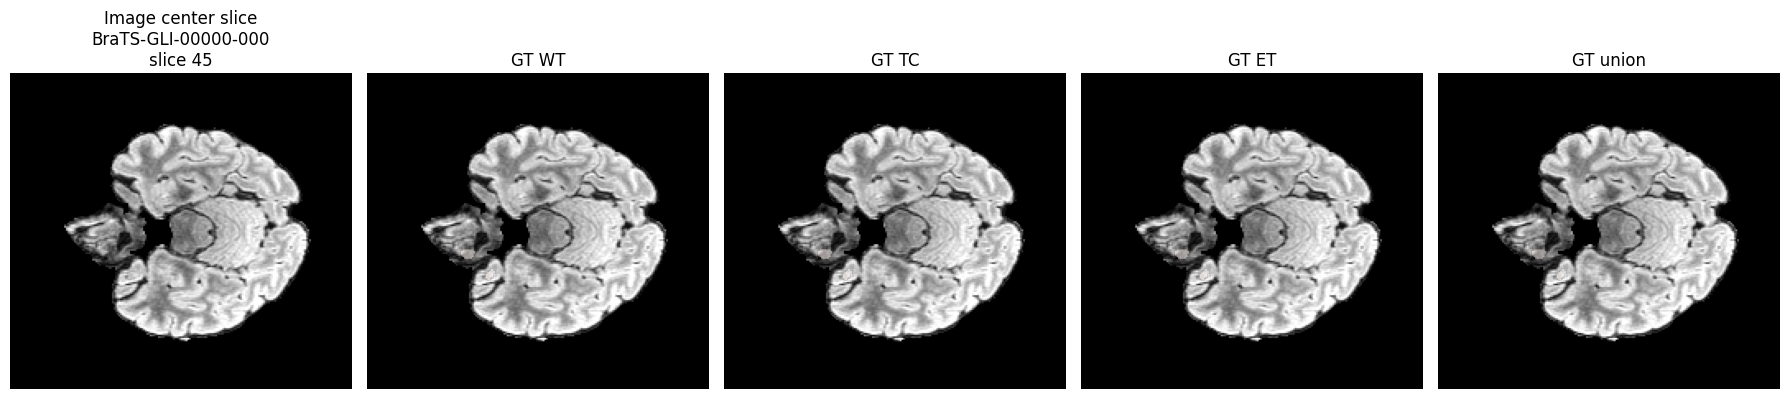

In [7]:
u.show_3d_slab_sample(train_dataset[0], region_names=REGION_NAMES, modality_index=3)


## 8. Core Component: 3D U-Net / 3D Attention U-Net Architecture


In [8]:
model_class = u.AttUNet3D if USE_ATTENTION_UNET_3D else u.UNet3D
model = model_class(
    in_channels=NUM_MODALITIES,
    out_channels=OUT_CHANNELS,
    base_channels=BASE_CHANNELS,
    pool_kernel=POOL_KERNEL_3D,
    upsample_scale=UPSAMPLE_SCALE_3D,
    norm_layer=NORM_LAYER_3D,
).to(DEVICE)

x_test = torch.randn(
    1,
    NUM_MODALITIES,
    SLAB_DEPTH,
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
).to(DEVICE)

with torch.no_grad():
    y_test = model(x_test)

print("Model class:", model.__class__.__name__)
print("Input shape:", x_test.shape)
print("Output shape:", y_test.shape)

expected_shape = (1, OUT_CHANNELS, SLAB_DEPTH, IMAGE_HEIGHT, IMAGE_WIDTH)
assert tuple(y_test.shape) == expected_shape, (
    f"Expected output shape {expected_shape}, got {tuple(y_test.shape)}"
)

num_params = sum(p.numel() for p in model.parameters())
num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {num_params:,}")
print(f"Trainable parameters: {num_trainable:,}")


Model class: UNet3D
Input shape: torch.Size([1, 4, 5, 192, 208])
Output shape: torch.Size([1, 3, 5, 192, 208])
Total parameters: 23,537,891
Trainable parameters: 23,537,891


## 9. Core Component: 3D Dice + BCE Loss


In [9]:
criterion = u.DiceBCELoss3D(dice_weight=1.0, bce_weight=1.0).to(DEVICE)
print(criterion)


DiceBCELoss3D(
  (dice_loss): DiceLoss3D()
  (bce_loss): BCEWithLogitsLoss()
)


## 10. Optimizer, Scheduler, and Backward Smoke Test


In [10]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
)

scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and DEVICE.type == "cuda"))

if RUN_BACKWARD_SMOKE_TEST:
    smoke_batch = next(iter(train_loader))
    smoke_images = smoke_batch["image"].to(DEVICE, non_blocking=True)
    smoke_labels = smoke_batch["label"].to(DEVICE, non_blocking=True)
    smoke_base_channels = min(BASE_CHANNELS, 8)
    smoke_model = model_class(
        in_channels=NUM_MODALITIES,
        out_channels=OUT_CHANNELS,
        base_channels=smoke_base_channels,
        pool_kernel=POOL_KERNEL_3D,
        upsample_scale=UPSAMPLE_SCALE_3D,
        norm_layer=NORM_LAYER_3D,
    ).to(DEVICE)
    smoke_optimizer = torch.optim.AdamW(
        smoke_model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    smoke_optimizer.zero_grad(set_to_none=True)
    smoke_logits = smoke_model(smoke_images)
    smoke_loss, smoke_parts = criterion(smoke_logits, smoke_labels)
    smoke_loss.backward()
    smoke_optimizer.step()

    print("Backward smoke test passed.")
    print("Smoke logits shape:", tuple(smoke_logits.shape))
    print("Smoke loss:", float(smoke_loss.detach().cpu()))
    print("Smoke loss parts:", smoke_parts)

    del smoke_model, smoke_optimizer, smoke_logits, smoke_loss
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print(optimizer)


/tmp/ipykernel_2982/3006037240.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and DEVICE.type == "cuda"))


Backward smoke test passed.
Smoke logits shape: (8, 3, 5, 192, 208)
Smoke loss: 1.5718598365783691
Smoke loss parts: {'dice_loss': 0.9582102298736572, 'bce_loss': 0.6136495471000671}
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


## 11. Core Component: Training and Validation Loops


In [11]:
# Training and validation are implemented in task3_unet3d_utils.py:
# - u.train_one_epoch_3d
# - u.validate_one_epoch_3d


## 12. 3D Slab Prediction Visualization


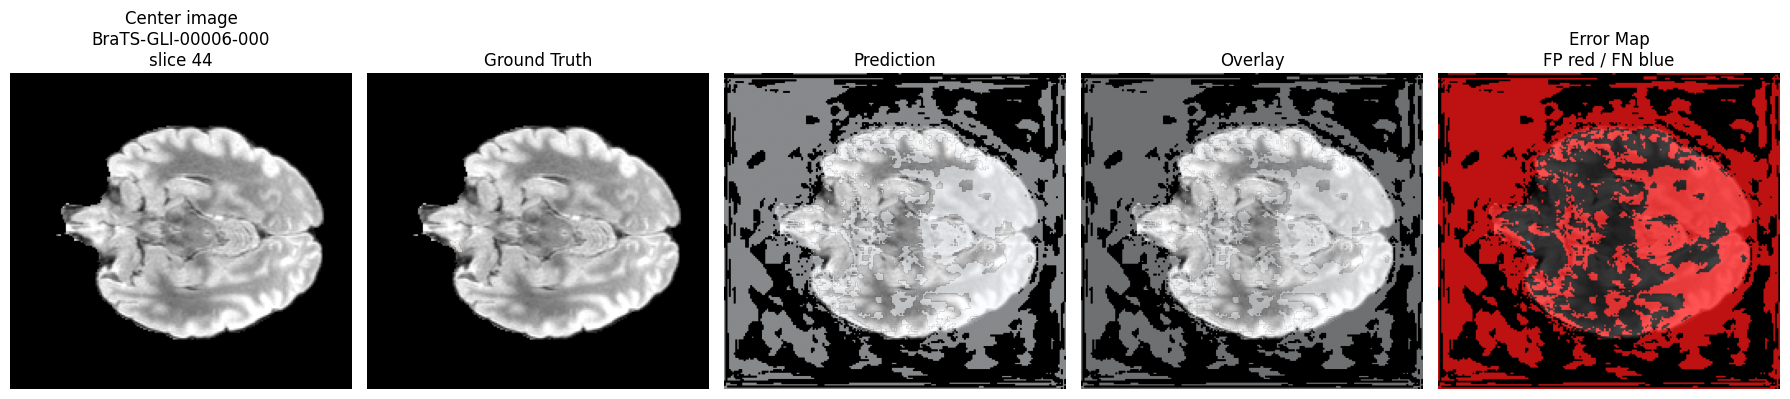

In [12]:
u.visualize_3d_slab_prediction(
    model=model,
    dataset=val_dataset,
    dataset_idx=0,
    device=DEVICE,
    save_path=OUTPUT_DIR / "prediction_before_training_center_slice.png",
    modality_index=3,
    threshold=THRESHOLD,
)


## 13. Main Training Loop


In [13]:
log_path = OUTPUT_DIR / "training_history.csv"
val_metrics_path = OUTPUT_DIR / "val_metrics.csv"
best_model_path = OUTPUT_DIR / "best_model.pt"
last_model_path = OUTPUT_DIR / "last_model.pt"

RESUME_TRAINING = True
RESUME_CHECKPOINT_PATH = last_model_path

history_fieldnames = [
    "epoch",
    "learning_rate",
    "lr",
    "train_loss",
    "train_dice_loss",
    "train_bce_loss",
    "val_loss",
    "val_dice_loss",
    "val_bce_loss",
    "val_dice",
    "dice_wt",
    "dice_tc",
    "dice_et",
    "mean_dice",
]

val_fieldnames = ["epoch", "loss", "dice_wt", "dice_tc", "dice_et", "mean_dice"]

start_epoch = 1
best_mean_dice = -1.0
epochs_without_improvement = 0
history = []


def initialize_csv(path, fieldnames):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()


def append_csv_row(path, fieldnames, row):
    with open(path, "a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writerow(row)


def get_best_mean_dice_from_log(log_path):
    if not Path(log_path).exists():
        return -1.0

    best_value = -1.0
    with open(log_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            for key in ("mean_dice", "val_dice"):
                if key in row:
                    try:
                        best_value = max(best_value, float(row[key]))
                    except ValueError:
                        pass

    return best_value


if RESUME_TRAINING and RESUME_CHECKPOINT_PATH.exists():
    print("Resuming training from checkpoint:")
    print(RESUME_CHECKPOINT_PATH)

    checkpoint = torch.load(RESUME_CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])

    if "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    if "scheduler_state_dict" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    checkpoint_epoch = int(checkpoint["epoch"])
    start_epoch = checkpoint_epoch + 1
    best_mean_dice = float(checkpoint.get("best_mean_dice", -1.0))
    epochs_without_improvement = int(checkpoint.get("epochs_without_improvement", 0))
    best_mean_dice = max(best_mean_dice, get_best_mean_dice_from_log(log_path))

    if not log_path.exists():
        initialize_csv(log_path, history_fieldnames)
    if not val_metrics_path.exists():
        initialize_csv(val_metrics_path, val_fieldnames)

    print(f"Checkpoint epoch: {checkpoint_epoch}")
    print(f"Resume from epoch: {start_epoch}")
    print(f"Current best mean Dice: {best_mean_dice:.4f}")
else:
    print("Starting training from scratch.")
    initialize_csv(log_path, history_fieldnames)
    initialize_csv(val_metrics_path, val_fieldnames)


if start_epoch > TOTAL_EPOCHS:
    print(
        f"Checkpoint epoch is already {start_epoch - 1}, "
        f"which is >= TOTAL_EPOCHS={TOTAL_EPOCHS}."
    )
    print("No further training will be performed.")
else:
    start_time = time.time()

    for epoch in range(start_epoch, TOTAL_EPOCHS + 1):
        print("=" * 80)
        print(f"Epoch {epoch}/{TOTAL_EPOCHS}")
        print("=" * 80)

        train_metrics = u.train_one_epoch_3d(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=DEVICE,
            scaler=scaler,
        )

        val_metrics = u.validate_one_epoch_3d(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=DEVICE,
            out_channels=OUT_CHANNELS,
            threshold=THRESHOLD,
        )

        scheduler.step(val_metrics["mean_dice"])
        lr = u.get_current_lr(optimizer)

        row = {
            "epoch": epoch,
            "learning_rate": lr,
            "lr": lr,
            "train_loss": train_metrics["loss"],
            "train_dice_loss": train_metrics["dice_loss"],
            "train_bce_loss": train_metrics["bce_loss"],
            "val_loss": val_metrics["loss"],
            "val_dice_loss": val_metrics["dice_loss"],
            "val_bce_loss": val_metrics["bce_loss"],
            "val_dice": val_metrics["mean_dice"],
            "dice_wt": val_metrics["dice_wt"],
            "dice_tc": val_metrics["dice_tc"],
            "dice_et": val_metrics["dice_et"],
            "mean_dice": val_metrics["mean_dice"],
        }
        history.append(row)

        print(
            f"LR: {lr:.6e} | "
            f"Train Loss: {row['train_loss']:.4f} | "
            f"Val Loss: {row['val_loss']:.4f} | "
            f"Dice WT: {row['dice_wt']:.4f} | "
            f"Dice TC: {row['dice_tc']:.4f} | "
            f"Dice ET: {row['dice_et']:.4f} | "
            f"Mean Dice: {row['mean_dice']:.4f}"
        )

        append_csv_row(log_path, history_fieldnames, row)
        append_csv_row(
            val_metrics_path,
            val_fieldnames,
            {
                "epoch": epoch,
                "loss": val_metrics["loss"],
                "dice_wt": val_metrics["dice_wt"],
                "dice_tc": val_metrics["dice_tc"],
                "dice_et": val_metrics["dice_et"],
                "mean_dice": val_metrics["mean_dice"],
            },
        )

        is_best = row["mean_dice"] > best_mean_dice
        if is_best:
            best_mean_dice = row["mean_dice"]
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_mean_dice": best_mean_dice,
            "epochs_without_improvement": epochs_without_improvement,
            "model_class": model.__class__.__name__,
            "config": {
                "num_modalities": NUM_MODALITIES,
                "out_channels": OUT_CHANNELS,
                "slab_depth": SLAB_DEPTH,
                "slab_mode": SLAB_MODE,
                "base_channels": BASE_CHANNELS,
                "pool_kernel_3d": POOL_KERNEL_3D,
                "upsample_scale_3d": UPSAMPLE_SCALE_3D,
                "norm_layer_3d": NORM_LAYER_3D,
                "image_height": IMAGE_HEIGHT,
                "image_width": IMAGE_WIDTH,
                "threshold": THRESHOLD,
                "use_attention_unet_3d": USE_ATTENTION_UNET_3D,
            },
        }

        torch.save(checkpoint, last_model_path)

        if is_best:
            torch.save(checkpoint, best_model_path)
            print(f"Saved new best model. Mean Dice = {best_mean_dice:.4f}")

        if epoch % VIS_EVERY_N_EPOCHS == 0 or epoch == TOTAL_EPOCHS:
            u.visualize_3d_slab_prediction(
                model=model,
                dataset=val_dataset,
                dataset_idx=0,
                device=DEVICE,
                save_path=OUTPUT_DIR / f"prediction_epoch_{epoch:03d}_center_slice.png",
                modality_index=3,
                threshold=THRESHOLD,
            )

        print(f"Early stopping counter: {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}")
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                f"Early stopping triggered after {epoch} epochs. "
                f"Best Mean Dice = {best_mean_dice:.4f}"
            )
            break

    elapsed = time.time() - start_time
    print()
    print("Training finished.")
    print(f"Best Mean Dice: {best_mean_dice:.4f}")
    print(f"Elapsed time: {elapsed / 60:.2f} minutes")
    print("Best model:", best_model_path)
    print("Last model:", last_model_path)
    print("Training history:", log_path)
    print("Validation metrics:", val_metrics_path)


Resuming training from checkpoint:
outputs_task3_unet3d_slab5/last_model.pt
Checkpoint epoch: 26
Resume from epoch: 27
Current best mean Dice: 0.9269
Epoch 27/50


Train:   0%|                                                                                                                                                                                                           | 0/3167 [00:00<?, ?it/s]/public/home/CS177/zhouzhj2023-cs177/MRI-segment/task3_unet3d_utils.py:691: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


LR: 1.250000e-05 | Train Loss: 0.0377 | Val Loss: 0.2768 | Dice WT: 0.9450 | Dice TC: 0.9118 | Dice ET: 0.9168 | Mean Dice: 0.9246
Early stopping counter: 21/20
Early stopping triggered after 27 epochs. Best Mean Dice = 0.9269

Training finished.
Best Mean Dice: 0.9269
Elapsed time: 30.61 minutes
Best model: outputs_task3_unet3d_slab5/best_model.pt
Last model: outputs_task3_unet3d_slab5/last_model.pt
Training history: outputs_task3_unet3d_slab5/training_history.csv
Validation metrics: outputs_task3_unet3d_slab5/val_metrics.csv


## 14. Plot Training Curves


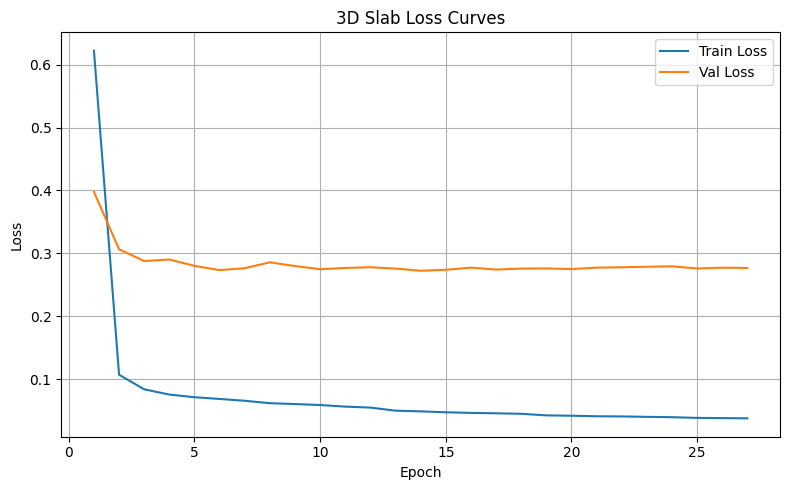

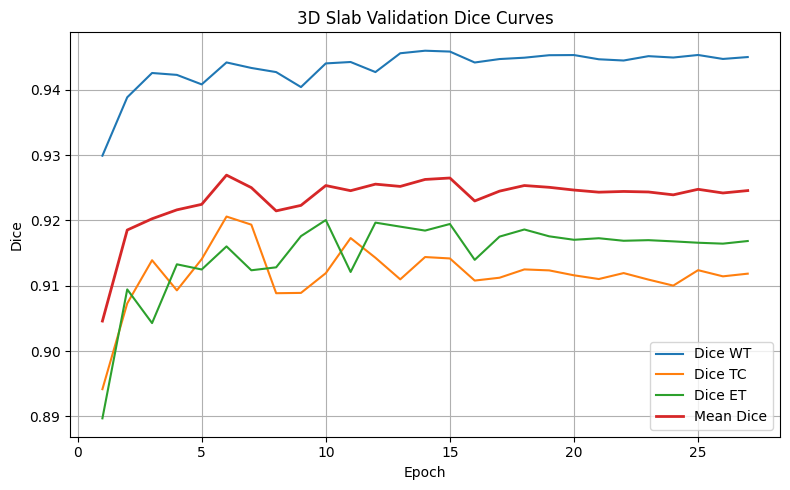

Best epoch log:
{'epoch': 6.0, 'learning_rate': 0.0001, 'lr': 0.0001, 'train_loss': 0.0685309971834639, 'train_dice_loss': 0.06013001020854822, 'train_bce_loss': 0.008400986978886263, 'val_loss': 0.27344181504600606, 'val_dice_loss': 0.2609176752435181, 'val_bce_loss': 0.01252413949134062, 'val_dice': 0.9269301516606979, 'dice_wt': 0.9441835532633261, 'dice_tc': 0.9205887014207453, 'dice_et': 0.9160182002980223, 'mean_dice': 0.9269301516606979}


In [14]:
def load_logs(log_path):
    rows = []
    with open(log_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append({k: float(v) for k, v in row.items()})
    return rows


logs = load_logs(log_path)
epochs = [r["epoch"] for r in logs]
train_loss = [r["train_loss"] for r in logs]
val_loss = [r["val_loss"] for r in logs]
dice_wt = [r["dice_wt"] for r in logs]
dice_tc = [r["dice_tc"] for r in logs]
dice_et = [r["dice_et"] for r in logs]
mean_dice = [r["mean_dice"] for r in logs]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("3D Slab Loss Curves")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curve.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, dice_wt, label="Dice WT")
plt.plot(epochs, dice_tc, label="Dice TC")
plt.plot(epochs, dice_et, label="Dice ET")
plt.plot(epochs, mean_dice, label="Mean Dice", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("3D Slab Validation Dice Curves")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "dice_curve.png", dpi=150)
plt.show()

best_idx = int(np.argmax(mean_dice))
print("Best epoch log:")
print(logs[best_idx])


## 15. Load Best Model and Visualize Final Validation Prediction


Loaded best model from epoch: 6
Best Mean Dice: 0.9269301516606979


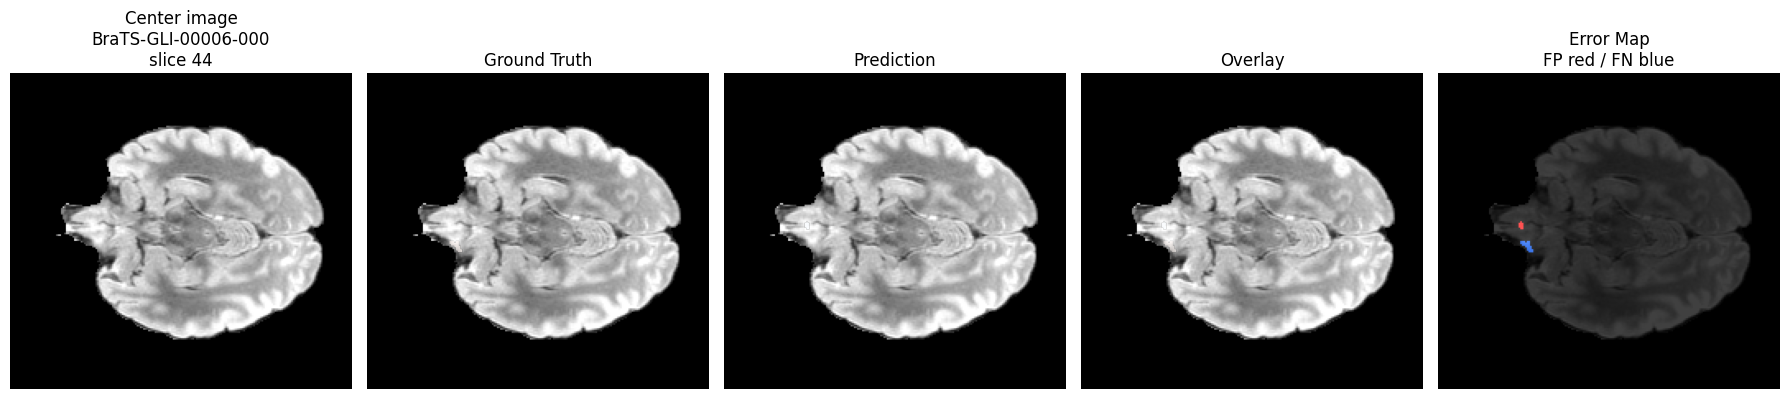

In [15]:
if "best_model_path" not in globals():
    best_model_path = OUTPUT_DIR / "best_model.pt"

best_checkpoint = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(best_checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

print("Loaded best model from epoch:", best_checkpoint["epoch"])
print("Best Mean Dice:", best_checkpoint["best_mean_dice"])

u.visualize_3d_slab_prediction(
    model=model,
    dataset=val_dataset,
    dataset_idx=0,
    device=DEVICE,
    save_path=OUTPUT_DIR / "prediction_best_model_center_slice.png",
    modality_index=3,
    threshold=THRESHOLD,
)


## 16. Test Evaluation: Slab-level Dice and Worst Cases


In [16]:
if "best_model_path" not in globals():
    best_model_path = OUTPUT_DIR / "best_model.pt"

metric_rows, summary_rows, worst_rows = u.run_test_evaluation_3d(
    model=model,
    test_loader=test_loader,
    test_dataset=test_dataset,
    device=DEVICE,
    output_dir=OUTPUT_DIR,
    best_model_path=best_model_path,
    region_names=REGION_NAMES,
    threshold=THRESHOLD,
    save_worst5=True,
)


Loaded best model for 3D test evaluation: outputs_task3_unet3d_slab5/best_model.pt
Checkpoint epoch: 6
Best validation mean Dice: 0.9269301516606979


Test slab Dice: 0.8851 +/- 0.1709
Test slab Loss: 0.1236 +/- 0.1733
Slab metrics: outputs_task3_unet3d_slab5/test_metrics.csv
Summary metrics: outputs_task3_unet3d_slab5/test_metrics_summary.csv
Worst 5 CSV: outputs_task3_unet3d_slab5/worst5_cases.csv
Worst 5 visualizations: outputs_task3_unet3d_slab5/worst5_visualizations


## 17. Notes for Report

- 3D input is `[B, 4, D, H, W]`; `D = SLAB_DEPTH`.
- 3D label is `[B, 3, D, H, W]`; WT/TC/ET remain three independent multilabel channels.
- The Dataset reads preprocessed 2D `.npz` slices, groups by patient, sorts by `slice_idx`, and stacks a fixed-depth slab on the depth axis.
- `center` slab mode gives every original slice a chance to be the center slice. Boundary slabs copy the nearest valid slice.
- The model uses `Conv3d`, `InstanceNorm3d`/`BatchNorm3d`, `MaxPool3d`, and trilinear 3D upsampling. It does not reshape 3D slabs into `[B, 4*D, H, W]`.
- Dice+BCE loss sums Dice over `(batch, depth, height, width)` and averages WT/TC/ET channel loss.
- Test evaluation is slab-level Dice/loss. 3D HD95 is intentionally not computed by reusing the older 2D HD95 helper.
